###Download Datasets

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


###Necessary Libraries

In [20]:
import os
import cv2
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, UpSampling2D, Flatten, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

###Dataset Creation

In [3]:
data_dir = os.path.join(path,"chest_xray/train")

normal_df = pd.DataFrame(columns=['filepaths', 'labels'])
pneumonia_df = pd.DataFrame(columns=['filepaths', 'labels'])

normal_label = 0
pneumonia_label = 1

normal_files = os.listdir(os.path.join(data_dir, "NORMAL"))
pneumonia_files = os.listdir(os.path.join(data_dir, "PNEUMONIA"))

normal_df['filepaths'] = [os.path.join(data_dir, "NORMAL", filename) for filename in normal_files]
normal_df['labels'] = normal_label

pneumonia_df['filepaths'] = [os.path.join(data_dir, "PNEUMONIA", filename) for filename in pneumonia_files]
pneumonia_df['labels'] = pneumonia_label


In [4]:
combined_df = pd.concat([normal_df, pneumonia_df], ignore_index=True)

label_counts = combined_df['labels'].value_counts()
print("\nLabel Counts:")
print(label_counts)


Label Counts:
labels
1    3875
0    1341
Name: count, dtype: int64


###Image Augmentation and Processing

In [5]:
def augment(img):
    datagen = ImageDataGenerator(
        shear_range=0.2,
        zoom_range=0.2,
    )

    img = np.expand_dims(img, 0)
    augmented_images = datagen.flow(img)

    return augmented_images[0]

def process_images(filepaths, image_size=(128, 128)):
    images = []
    for path in filepaths:
        try:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, image_size)
            img = img.astype(np.float32) / 255.0

            augmented_img = augment(img)
            augmented_img = np.squeeze(augmented_img, axis=0)

            images.append(augmented_img)
        except Exception as e:
            print(f"Error processing image at path: {path}")
            print(f"Details: {str(e)}")

    return tf.convert_to_tensor(images)

normal_tensor = process_images(normal_df['filepaths'].values)
pneumonia_tensor = process_images(pneumonia_df['filepaths'].values)

print("Normal Tensor Shape:", normal_tensor.shape)
print("Pneumonia Tensor Shape:", pneumonia_tensor.shape)

Normal Tensor Shape: (1341, 128, 128, 3)
Pneumonia Tensor Shape: (3875, 128, 128, 3)


###Data Splitting and Dataset Preparation

In [6]:
# Create label arrays for normal and pneumonia cases
normal_labels = np.zeros(len(normal_tensor), dtype=np.int64)
pneumonia_labels = np.ones(len(pneumonia_tensor), dtype=np.int64)

# Concatenate labels to form a single label array
labels = np.concatenate((normal_labels, pneumonia_labels), axis=0)

# Concatenate processed image tensors
images = np.concatenate((normal_tensor, pneumonia_tensor), axis=0)

# Split the dataset into training and testing sets, ensuring stratified sampling
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels)

# Create TensorFlow datasets from the split data
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

In [7]:
train_dataset_cardinality = train_dataset.cardinality()
print("Number of elements in train_dataset:", train_dataset_cardinality)

test_dataset_cardinality = test_dataset.cardinality()
print("Number of elements in test_dataset:", test_dataset_cardinality)

Number of elements in train_dataset: tf.Tensor(4172, shape=(), dtype=int64)
Number of elements in test_dataset: tf.Tensor(1044, shape=(), dtype=int64)


In [8]:
# Define the batch size for training and evaluation
batch_size = 32

# Shuffle and batch the training dataset
train_data = train_dataset.shuffle(10000).batch(batch_size)

# Batch the test dataset (shuffling is typically not needed for test data)
test_data = test_dataset.batch(batch_size)

In [9]:
for image,label in train_data.take(1):
    print(image.shape)

(32, 128, 128, 3)


###Data Visualization

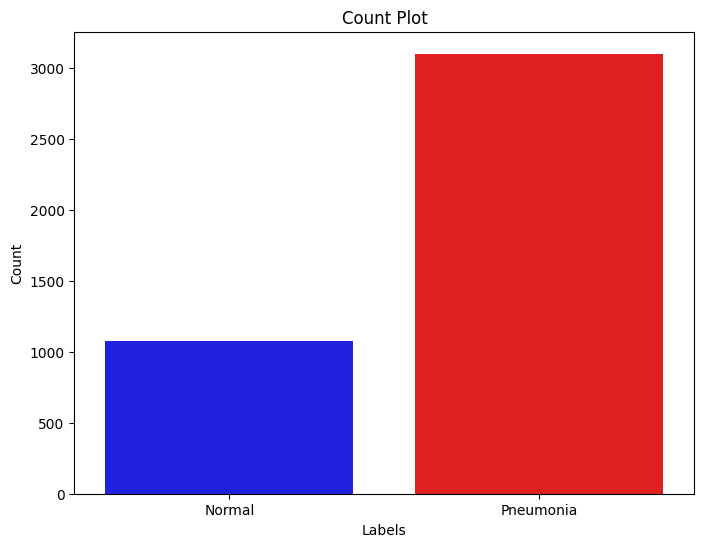

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x=train_labels,
    hue=train_labels,
    palette={0: 'blue', 1: 'red'},   # Normal = blue, Pneumonia = red
    legend=False
)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Pneumonia'])
plt.title('Count Plot')
plt.show()

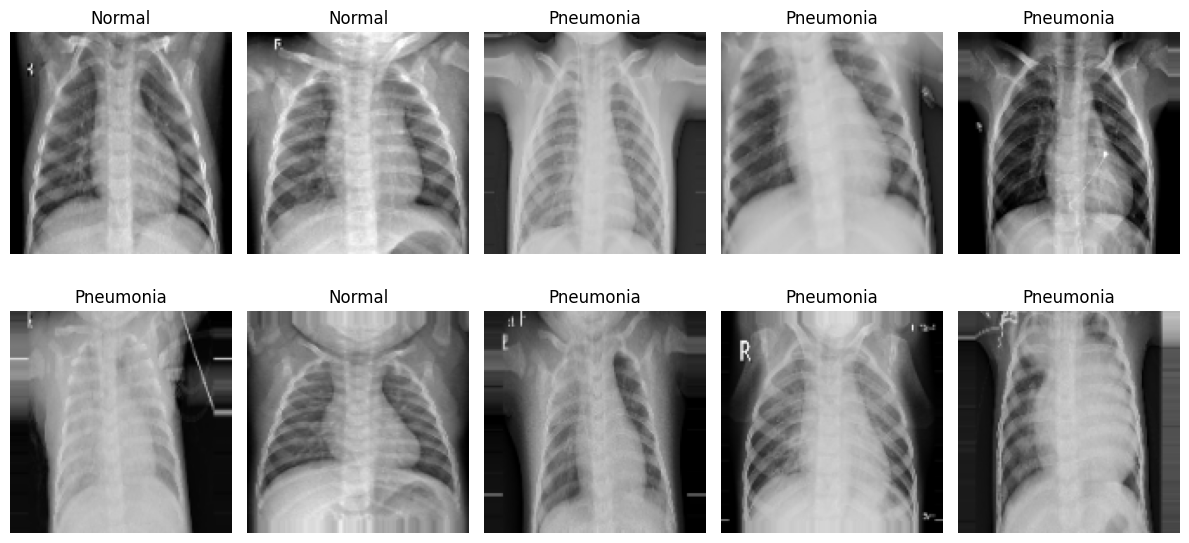

In [11]:
label_names = ['Normal', 'Pneumonia']

def plot_images(images, labels, rows=2, cols=5):
    plt.figure(figsize=(12, 6))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(label_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_images(train_images[:10], train_labels[:10])

###Data Oversampling

In [12]:
normal_indices = np.where(train_labels == 0)[0]
pneumonia_indices = np.where(train_labels == 1)[0]

# Count the number of samples for each class
normal_count = len(normal_indices)
pneumonia_count = len(pneumonia_indices)

print(f"Original Normal count: {normal_count}")
print(f"Original Pneumonia count: {pneumonia_count}")

# Calculate the number of additional 'NORMAL' samples required
num_to_oversample = pneumonia_count - normal_count

# Randomly select additional 'NORMAL' samples with replacement
if num_to_oversample > 0:
    oversampled_indices = np.random.choice(normal_indices, size=num_to_oversample, replace=True)

    # Get the oversampled images and labels
    oversampled_normal_images = train_images[oversampled_indices]
    oversampled_normal_labels = train_labels[oversampled_indices]

    # Concatenate the oversampled 'NORMAL' samples with the original training data
    train_images_oversampled = np.concatenate((train_images, oversampled_normal_images), axis=0)
    train_labels_oversampled = np.concatenate((train_labels, oversampled_normal_labels), axis=0)
else:
    train_images_oversampled = train_images
    train_labels_oversampled = train_labels

# Verify the new class distribution
new_normal_count = np.sum(train_labels_oversampled == 0)
new_pneumonia_count = np.sum(train_labels_oversampled == 1)

print(f"\nNew Normal count after oversampling: {new_normal_count}")
print(f"New Pneumonia count after oversampling: {new_pneumonia_count}")

# Update the train_data by creating a new TensorFlow dataset
train_dataset_oversampled = tf.data.Dataset.from_tensor_slices((train_images_oversampled, train_labels_oversampled))
train_data = train_dataset_oversampled.shuffle(10000).batch(batch_size)

print(f"Number of elements in oversampled train_dataset: {train_dataset_oversampled.cardinality()}")

Original Normal count: 1073
Original Pneumonia count: 3099

New Normal count after oversampling: 3099
New Pneumonia count after oversampling: 3099
Number of elements in oversampled train_dataset: 6198


##Autoencoder

###Autoencoder-based Encoder and Classifier

In [14]:
input_img = Input(shape=(128, 128, 3)) # Input layer for 128x128x3 images

# Encoder part
x = Conv2D(8, (3, 3), activation='relu', padding='same')(input_img) # First convolutional layer with 8 filters
x = MaxPool2D((2, 2), padding='same')(x) # First max pooling layer
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x) # Second convolutional layer with 16 filters
x= MaxPool2D((2, 2), padding='same')(x) # Second max pooling layer
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x) # Third convolutional layer with 32 filters
encoded = MaxPool2D((2, 2), padding='same')(x) # Output of the encoder, compressed representation

# Decoder part
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded) # First deconvolutional layer, same as last encoder layer
x = UpSampling2D((2, 2))(x) # First upsampling layer
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x) # Second deconvolutional layer
x = UpSampling2D((2, 2))(x) # Second upsampling layer
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x) # Third deconvolutional layer
x = UpSampling2D((2, 2))(x) # Third upsampling layer
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Output layer, reconstructing the original image

autoencoder = Model(input_img, decoded) # Create the autoencoder model
autoencoder.compile(optimizer='adam', loss='mse') # Compile the autoencoder with Adam optimizer and Mean Squared Error loss

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,283 (83.14 KB)

 Trainable params: 21,283 (83.14 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoencoder.fit(train_images, train_images, epochs=5, batch_size=16)

Epoch 1/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 56s 207ms/step - loss: 0.0093
Epoch 2/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 52s 200ms/step - loss: 0.0030
Epoch 3/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 92s 238ms/step - loss: 0.0024
Epoch 4/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 89s 265ms/step - loss: 0.0021
Epoch 5/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 68s 261ms/step - loss: 0.0019


In [16]:
encoder = Model(input_img, encoded) # Create an encoder model from the input to the encoded layer

classifier_input = Input(shape=(16, 16, 32)) # Input layer for the classifier, matching the shape of 'encoded' output
x = Flatten()(classifier_input) # Flatten the encoded image into a 1D vector
x = Dense(128, activation='relu')(x) # Fully connected layer with 128 neurons and ReLU activation
x = Dense(1, activation='sigmoid')(x) # Output layer with a single neuron and sigmoid activation for binary classification
model_encoder = Model(classifier_input, x) # Create the classifier model

model_encoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compile the classifier with Adam optimizer, binary crossentropy loss, and accuracy metric
print(model_encoder.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,048,833 (4.00 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

None


###Model Training

In [17]:
encoded_train = encoder.predict(train_images)
encoded_test= encoder.predict(test_images)

history_encoder= model_encoder.fit(encoded_train, train_labels, epochs=5, batch_size=32, validation_data=(encoded_test, test_labels))

131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8315 - loss: 0.3874 - val_accuracy: 0.9148 - val_loss: 0.2394
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9041 - loss: 0.2309 - val_accuracy: 0.9215 - val_loss: 0.1958
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9219 - loss: 0.1910 - val_accuracy: 0.9272 - val_loss: 0.1798
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9187 - loss: 0.1944 - val_accuracy: 0.9253 - val_loss: 0.1858
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9310 - loss: 0.1680 - val_accuracy: 0.8841 - val_loss: 0.2852


###Training and Validation Metrics Visualization

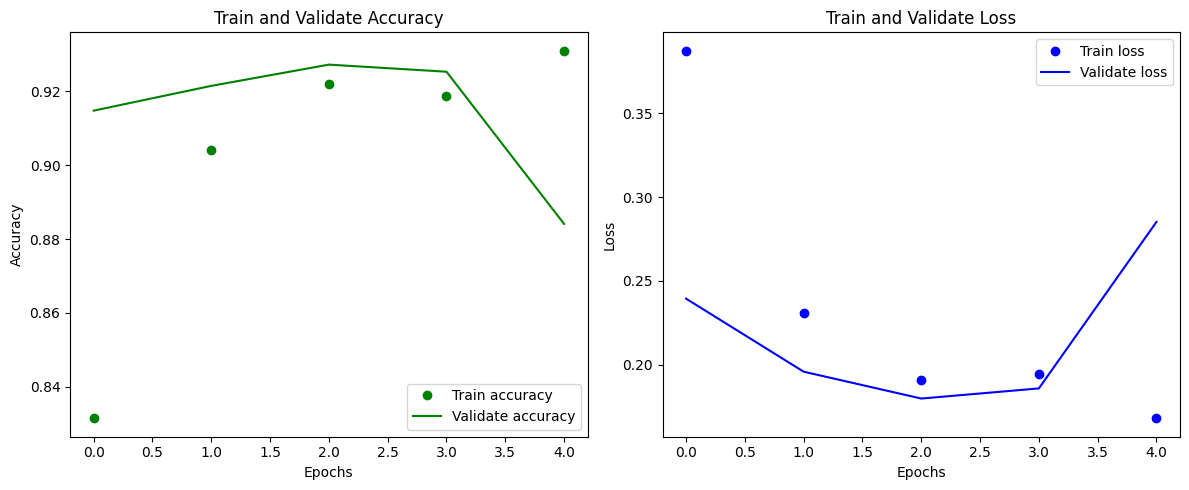

In [18]:
acc = history_encoder.history['accuracy']
val_acc = history_encoder.history['val_accuracy']
loss = history_encoder.history['loss']
val_loss = history_encoder.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, 'go', label='Train accuracy')
plt.plot(val_acc, 'g', label='Validate accuracy')
plt.title('Train and Validate Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, 'bo', label='Train loss')
plt.plot(val_loss, 'b', label='Validate loss')
plt.title('Train and Validate Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

###Model Evaluation

In [21]:
probabilities = model_encoder.predict(encoded_test)
predicted_classes = (probabilities > 0.5).astype(int)

report = classification_report(test_labels, predicted_classes)
print(report)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.70      0.97      0.81       268
           1       0.99      0.86      0.92       776

    accuracy                           0.88      1044
   macro avg       0.84      0.91      0.86      1044
weighted avg       0.91      0.88      0.89      1044



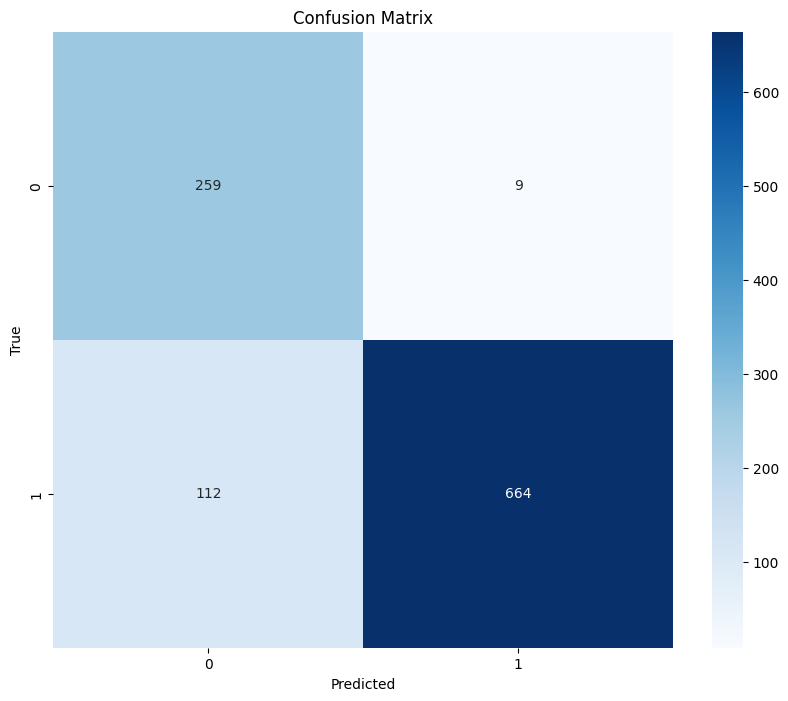

In [22]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [23]:
results = model_encoder.evaluate(encoded_test,test_labels, verbose=True)

loss = round(results[0], 2)
accuracy = round(results[1] * 100, 2)

print(f'Test results - Loss: {loss} - Accuracy: {accuracy}%')

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8841 - loss: 0.2852
Test results - Loss: 0.29 - Accuracy: 88.41%


###Prediction using Autoencoder based Model

In [25]:
def predict_pneumonia_or_normal(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return "Error: Image not found or corrupted"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    encoded_img = encoder.predict(img, verbose=0)

    prediction = model_encoder.predict(encoded_img, verbose=0)

    if prediction[0] > 0.5:
        return '\nPrediction: Pneumonia (Class 1)\n'
    else:
        return '\nPrediction: Normal (Class 0)\n'

# Correcting the base path for test images
# The dataset is located at '/kaggle/input/chest-xray-pneumonia'
# So, the test images are under '/kaggle/input/chest-xray-pneumonia/chest_xray/test/'
base_test_path = os.path.join(path, "chest_xray", "test")

img_paths = [
    os.path.join(base_test_path, 'PNEUMONIA', 'person101_bacteria_484.jpeg'),
    os.path.join(base_test_path, 'PNEUMONIA', 'person102_bacteria_487.jpeg'),
    os.path.join(base_test_path, 'NORMAL', 'IM-0007-0001.jpeg'),
    os.path.join(base_test_path, 'NORMAL', 'IM-0009-0001.jpeg')
]

for img_path in img_paths:
    prediction = predict_pneumonia_or_normal(img_path)
    print(f'For image {img_path}, {prediction}')

For image /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person101_bacteria_484.jpeg, 
Prediction: Pneumonia (Class 1)

For image /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person102_bacteria_487.jpeg, 
Prediction: Pneumonia (Class 1)

For image /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0007-0001.jpeg, 
Prediction: Normal (Class 0)

For image /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0009-0001.jpeg, 
Prediction: Normal (Class 0)

